# Comparing NUTS, ADVI, full-rank ADVI and Pathfinder

Fit exactly the same ARMA model and priors four ways. Compare parameter estimates,
fit time, forecast time, CRPS and 90% interval coverage. No engine changes the model
or sees the test observations during fitting.

This adapts the idea of [Juan Orduz's inference comparison](https://github.com/juanitorduz/numpyro_forecast/blob/main/docs/examples/inference_methods_comparison.ipynb)
to the inference methods already supported by PyMC-Forecast. Install the `extras`
extra for Pathfinder. All four engines run in CI with reduced settings.

In [1]:
import os
from time import perf_counter

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import xarray as xr

from pymc_forecast import (
    Forecaster,
    HMCForecaster,
    PathfinderForecaster,
    evaluate_forecast,
    ssoe,
)

SMOKE = os.getenv("PYMC_FORECAST_SMOKE_TEST") == "1"
SEED = 2026
rng = np.random.default_rng(SEED)
DRAWS, TUNE, CHAINS = (25, 25, 1) if SMOKE else (600, 800, 2)
N_PRED = 50 if SMOKE else 800
plt.rcParams.update({"figure.figsize": (10, 4), "figure.dpi": 110})
print(
    "Execution mode:", "CI smoke check; do not interpret fit quality" if SMOKE else "full example"
)

Execution mode: full example


## Shared data and model

In [2]:
phi_true, theta_true, sigma_true = 0.65, 0.25, 0.4
n_train, horizon = 140, 24
errors = rng.normal(0, sigma_true, n_train + horizon)
values = np.zeros(n_train + horizon)
previous_y = previous_error = 0.0
for i, error in enumerate(errors):
    values[i] = phi_true * previous_y + theta_true * previous_error + error
    previous_y, previous_error = values[i], error
series = xr.DataArray(
    values, dims="time", coords={"time": pd.date_range("2024-01-01", periods=len(values), freq="D")}
)
train = series.isel(time=slice(n_train))
truth = series.isel(time=slice(n_train, None)).rename(time="time_future")

In [3]:
def arma_model(h, covariates):
    phi = pm.Uniform("phi", -0.95, 0.95)
    theta = pm.Uniform("theta", -0.95, 0.95)
    sigma = pm.HalfNormal("sigma", 1.0)

    def mean(state, x, phi, theta):
        previous_y, previous_error = state
        return phi * previous_y + theta * previous_error

    def update(state, y, error, x, phi, theta):
        return y, error

    r = ssoe(
        h,
        "eps",
        (0.0, 0.0),
        mean,
        update,
        lambda name, dims: pm.Normal(name, 0, sigma, dims=dims),
        params=(phi, theta),
    )
    pm.Normal("obs", r.mu, sigma, observed=h.data.values, dims="time")
    pm.Deterministic("mu", r.mu, dims="time")
    if h.future:
        pm.Deterministic("mu_future", r.mu_future, dims="time_future")
        pm.Deterministic("forecast", r.y_future, dims="time_future")

## Fit all four engines

These timings include model building and compilation. They are one run on one
machine, not a hardware-independent benchmark; compilation caches and execution
order can affect the comparison. NUTS diagnostics apply to its actual chains.
Approximation draws from ADVI and Pathfinder must not be interpreted as MCMC chains.

In [4]:
steps = 100 if SMOKE else 30000
specs = {
    "NUTS": (
        HMCForecaster,
        {"draws": DRAWS, "tune": TUNE, "chains": CHAINS, "sample_kwargs": {"target_accept": 0.9}},
    ),
    "ADVI": (Forecaster, {"num_steps": steps, "optimizer": 0.005}),
    "Full-rank ADVI": (
        Forecaster,
        {"method": "fullrank_advi", "num_steps": steps, "optimizer": 0.005},
    ),
    "Pathfinder": (
        PathfinderForecaster,
        {
            "pathfinder_kwargs": {
                "num_paths": 2 if SMOKE else 4,
                "num_draws": N_PRED,
                "num_draws_per_path": 100 if SMOKE else 500,
                "maxiter": 100 if SMOKE else 1000,
                "concurrent": None,
            }
        },
    ),
}
fits, forecasts, posteriors, rows = {}, {}, {}, []
for i, (name, (cls, options)) in enumerate(specs.items()):
    start = perf_counter()
    fit = cls(arma_model, train, random_seed=SEED + i, progressbar=False, **options)
    fit_seconds = perf_counter() - start
    posterior = fit.draw_posterior(N_PRED, random_seed=SEED + 20 + i)
    start = perf_counter()
    samples = fit.forecast(
        horizon=horizon, posterior=posterior, random_seed=SEED + 30 + i
    ).predictions.forecast
    forecast_seconds = perf_counter() - start
    fits[name], forecasts[name], posteriors[name] = fit, samples, posterior
    assert samples.dims == ("chain", "draw", "time_future")
    rows.append(
        {
            "method": name,
            "fit_seconds": fit_seconds,
            "forecast_seconds": forecast_seconds,
            **evaluate_forecast(samples, truth),
        }
    )
pd.DataFrame(rows).set_index("method").round(3)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [phi, theta, sigma]


Sampling 2 chains for 800 tune and 600 draw iterations (1_600 + 1_200 draws total) took 14 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


...

Finished [100%]: Average Loss = 85.88


Sampling: [eps_future]


Pathfinder Results                          
                                            
  No. model parameters     3                
                                            
  Configuration:                            
  num_draws_per_path       500              
  history size (maxcor)    5                
  max iterations           1000             
  ftol                     1.00e-05         
  gtol                     1.00e-08         
  max line search          1000             
  jitter                   2.0              
  epsilon                  1.00e-12         
  ELBO draws               10               
                                            
  LBFGS Status:                             
  CONVERGED                4                
  L-BFGS iterations        mean 15 ± std 3  
                                            
  Path Status:                              
  SUCCESS                  4                
  ELBO argmax              mean 12 ± std 2  
                                            
  Importance Sampling:                      
  Method                   psis             
  Pareto k                 0.63             
                                            
  Timing (seconds):                         
  Compile                  2.65             
  Compute                  1.13             
  Total                    3.78

Sampling: [eps_future]


,fit_seconds,forecast_seconds,mae,rmse,crps,coverage
method,,,,,,
NUTS,19.711,1.867,0.554,0.710,0.402,0.875
ADVI,36.336,0.340,0.550,0.714,0.403,0.875
Full-rank ADVI,27.356,0.609,0.567,0.713,0.405,0.875
Pathfinder,5.902,0.358,0.551,0.700,0.396,0.875


## Parameter estimates and diagnostics

In [5]:
parameter_means = pd.DataFrame(
    {
        name: {v: float(posterior[v].mean()) for v in ["phi", "theta", "sigma"]}
        for name, posterior in posteriors.items()
    }
)
parameter_means["simulation_truth"] = [phi_true, theta_true, sigma_true]
parameter_means

,NUTS,ADVI,Full-rank ADVI,Pathfinder,simulation_truth
phi,0.687089,0.689719,0.682060,0.682939,0.65
theta,0.299271,0.286084,0.323786,0.297085,0.25
sigma,0.428679,0.426532,0.437077,0.426495,0.40


In [6]:
az.summary(fits["NUTS"].idata, var_names=["phi", "theta", "sigma"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
phi,0.689,0.075,0.551,0.821,0.003,0.002,727.0,576.0,1.0
theta,0.298,0.092,0.125,0.469,0.003,0.003,899.0,816.0,1.0
sigma,0.429,0.026,0.383,0.480,0.001,0.001,960.0,995.0,1.0


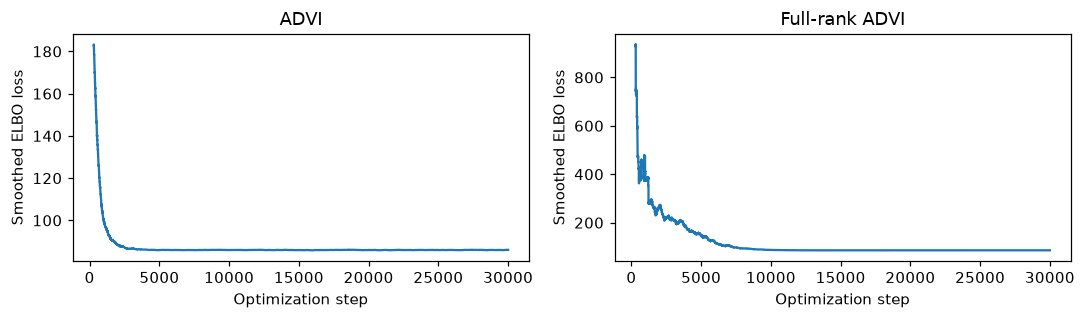

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
for ax, name in zip(axes, ["ADVI", "Full-rank ADVI"], strict=True):
    loss = pd.Series(fits[name].losses)
    loss.rolling(max(5, len(loss) // 100)).mean().plot(ax=ax)
    ax.set(title=name, xlabel="Optimization step", ylabel="Smoothed ELBO loss")
fig.tight_layout()
plt.show()

In [8]:
def plot_forecast(ax, samples, truth, label="forecast", color="C0"):
    time = samples.time_future.values
    q = samples.quantile([0.05, 0.5, 0.95], dim=("chain", "draw"))
    ax.fill_between(
        time,
        q.sel(quantile=0.05),
        q.sel(quantile=0.95),
        alpha=0.2,
        color=color,
        label=f"{label}: 90% interval",
    )
    ax.plot(time, q.sel(quantile=0.5), color=color, label=f"{label}: median")
    ax.plot(time, truth.values, color="black", lw=1, label="held-out observations")
    ax.set(xlabel="Date", ylabel="Value")
    ax.legend(loc="upper left")

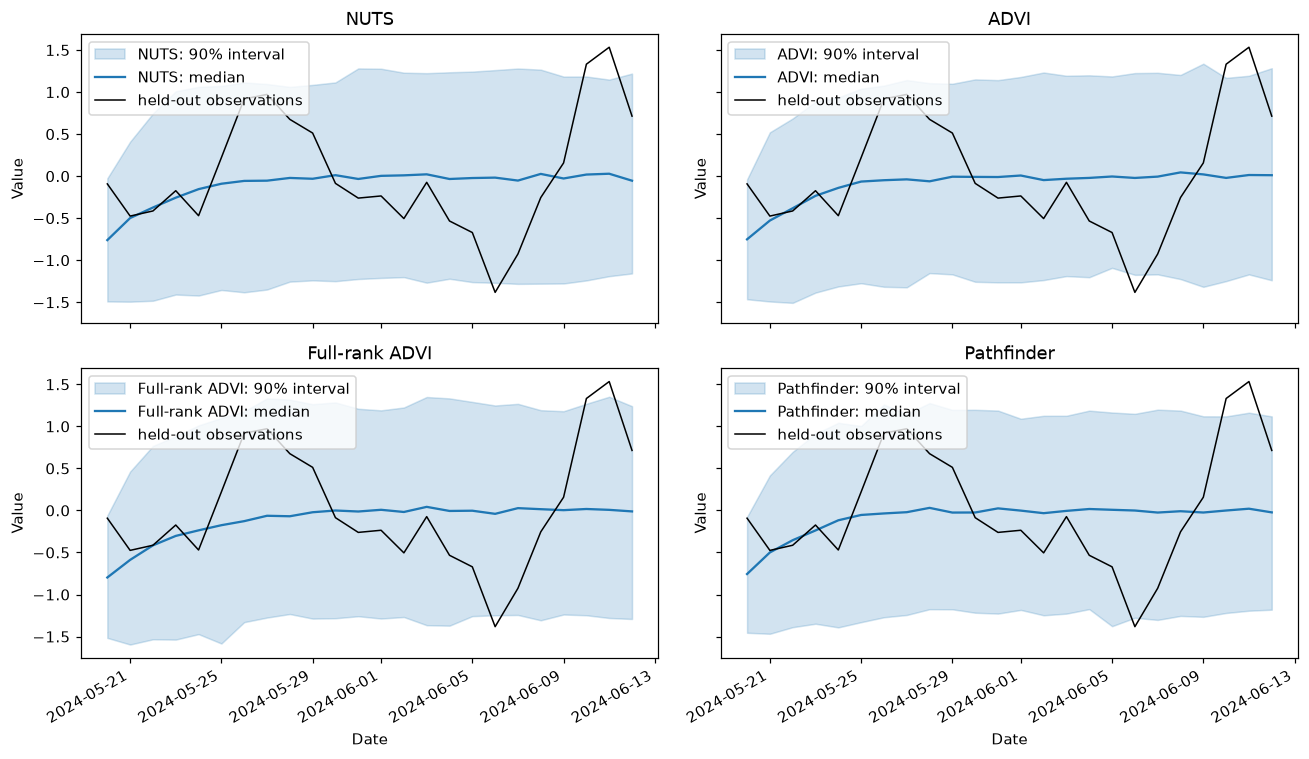

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True, sharey=True)
for ax, (name, samples) in zip(axes.flat, forecasts.items(), strict=True):
    plot_forecast(ax, samples, truth, label=name)
    ax.set_title(name)
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

## How to use the comparison

Read predictive scores together with diagnostics and posterior uncertainty. Similar
point estimates can hide different interval widths. An unfinished ELBO optimization
is not a fair assessment of ADVI; increase its steps or adjust its optimizer if needed.
Pathfinder's importance-sampling diagnostics can also indicate an unreliable approximation.

A single 24-day holdout gives noisy coverage estimates. Use the [ARMA backtest](arma.ipynb)
to repeat the comparison across forecast origins before choosing an engine for an application.
CI smoke outputs only confirm that the workflow executes.